In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Esercizio 02.1

In questo esercizio voglio calcolare numericamente l'integrale

$$
I=\int_0^{\pi/2} \frac{\pi}{2}\cos\left(\frac{\pi}{2}x\right)\,dx
$$

utilizzando il metodo Monte Carlo e confrontando due diverse modalità di campionamento: un campionamento uniforme e un campionamento non uniforme tramite importance sampling.

In entrambi i casi utilizzo $N=10000$ estrazioni, suddivise in $M=100$ blocchi da $n=100$ lanci ciascuno. Per ogni blocco calcolo il valor medio dell'integrale e il suo quadrato, e successivamente applico il metodo del data blocking per ottenere il valore medio progressivo e la relativa incertezza statistica.

### 1. Campionamento uniforme

Nel primo caso estraggo una variabile casuale $x$ con distribuzione uniforme nell'intervallo $[0,1]$.

L'integrale viene quindi stimato direttamente come media dei valori della funzione

$$
f(x)=\frac{\pi}{2}\cos\left(\frac{\pi}{2}x\right).
$$

Per ogni estrazione calcolo quindi

$$
x=\frac{\pi}{2}\cos\left(r\frac{\pi}{2}\right),
$$

dove $r$ è un numero casuale uniforme tra $0$ e $1$.

Il valore medio ottenuto in ciascun blocco viene poi utilizzato nel data blocking per costruire la stima progressiva dell'integrale:

$$
\overline I_n=
\frac{1}{n}\sum_{i=1}^{n}I_i.
$$

L'errore statistico viene calcolato tramite

$$
\sigma=
\sqrt{
\frac{\langle I^2\rangle-\langle I\rangle^2}{n}
}.
$$


### 2. Importance sampling

Nel secondo caso utilizzo invece un campionamento non uniforme, scegliendo una distribuzione di probabilità $p(x)$ che sia simile alla forma della funzione integranda.

In particolare, scelgo

$$
p(x)=2(1-x),
\qquad x\in[0,1].
$$

Questa distribuzione è normalizzata nell'intervallo considerato:

$$
\int_0^1 2(1-x)\,dx=1.
$$

Per generare variabili casuali distribuite secondo $p(x)$ utilizzo il metodo della trasformazione inversa. Partendo dalla distribuzione cumulativa

$$
P(x)=\int_0^x2(1-t)\,dt
=2x-x^2,
$$

e ponendo $P(x)=r$, con $r$ uniforme in $[0,1]$, ottengo

$$
x=1-\sqrt{1-r}.
$$

È proprio questa relazione che viene utilizzata nel codice per generare $x$.

Poiché il campionamento non è uniforme, non posso più calcolare semplicemente la media della funzione $f(x)$. Devo invece compensare la diversa probabilità di estrazione dividendo la funzione per la distribuzione utilizzata:

$$
I=
\int_0^1 f(x)\,dx
=
\int_0^1
\frac{f(x)}{p(x)}p(x)\,dx.
$$

Pertanto, per ogni estrazione calcolo

$$
\frac{f(x)}{p(x)}
=
\frac{
\frac{\pi}{2}\cos\left(\frac{\pi}{2}x\right)
}{
2(1-x)
}.
$$

Anche in questo caso i risultati vengono suddivisi in blocchi e viene applicato il data blocking per ottenere il valor medio progressivo e la relativa incertezza.


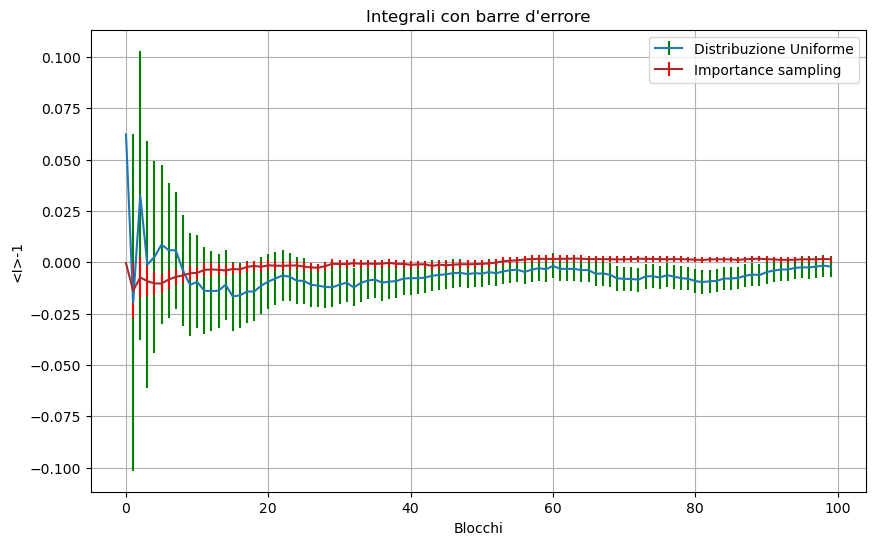

In [15]:
data1 = np.loadtxt("sim_num_es02.1/uniform.dat")
int1 = data1[:, 0]
err1 = data1[:, 1]
pass1 = data1[:, 2]

data2 = np.loadtxt("sim_num_es02.1/non_uniform.dat")
int2 = data2[:, 0]
err2 = data2[:, 1]
pass2 = data2[:, 2]

plt.figure(figsize=(10,6))


plt.errorbar(pass1, int1-1, yerr=err1, ecolor='green', label="Distribuzione Uniforme")
plt.errorbar(pass2, int2-1, yerr=err2, color="brown", ecolor='red', label="Importance sampling")

plt.xlabel('Blocchi')
plt.ylabel('<I>-1')
plt.title("Integrali con barre d'errore")
plt.grid(True)
plt.legend()
plt.show()

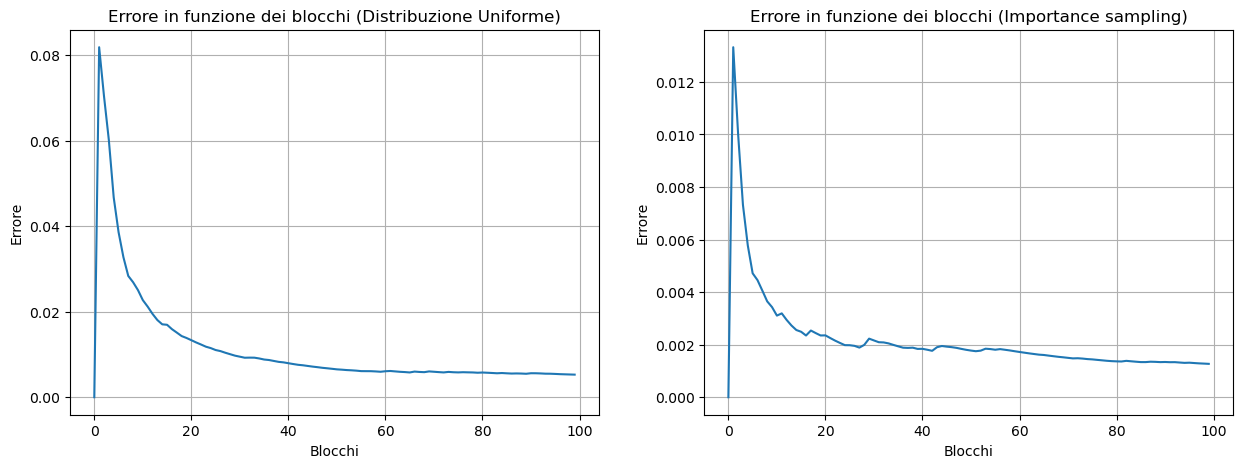

In [16]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(err1)
plt.xlabel('Blocchi')
plt.ylabel('Errore')
plt.title("Errore in funzione dei blocchi (Distribuzione Uniforme)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(err2)
plt.xlabel('Blocchi')
plt.ylabel('Errore')
plt.title("Errore in funzione dei blocchi (Importance sampling)")
plt.grid(True)
plt.show()

## Commento

Si osserva che, con entrambi i metodi, dopo un numero sufficiente di blocchi si converge al valore esatto dell'integrale. Dai grafici si notano però delle differenze per quanto riguarda le barre d'errore e le fluttuazioni dei valori: il campionamento uniforme presenta errori e fluttuazioni più marcati, mentre con l'importance sampling si ottengono errori più piccoli e una convergenza più stabile.

Questo comportamento è dovuto alla diversa distribuzione utilizzata per il campionamento. Nel caso uniforme si calcola direttamente la media di $f(x)$, che può assumere valori significativamente diversi nell'intervallo considerato, generando quindi fluttuazioni relativamente elevate.

Con l'importance sampling, invece, si calcola la media di $f(x)/p(x)$, dove $p(x)$ è stata scelta in modo da avere un andamento simile a quello di $f(x)$. Di conseguenza, il rapporto $f(x)/p(x)$ risulta molto più uniforme e i valori campionati sono più simili tra loro. Questo comporta una riduzione della varianza e, di conseguenza, una diminuzione dell'incertezza sulla stima dell'integrale.


# Esercizio 02.2

In questo esercizio studio il comportamento di una random walk tridimensionale, considerando due diversi casi: una random walk su reticolo e una random walk nello spazio continuo. L'obiettivo è studiare l'andamento della distanza quadratica media dall'origine al variare del numero di passi.

Per entrambe le simulazioni considero

$$
M=10000
$$

random walk, ciascuna costituita da

$$
N=100
$$

passi. Per effettuare il data blocking divido le $10000$ random walk in

$$
m=100
$$

blocchi, contenenti quindi

$$
L=\frac{M}{m}=100
$$

random walk ciascuno.

### 1. Random walk su reticolo

Nel caso discreto considero un reticolo cubico tridimensionale e parto sempre dall'origine

$$
(x,y,z)=(0,0,0).
$$

Ad ogni passo scelgo casualmente una delle sei possibili direzioni:

$$
+x,\;-x,\;+y,\;-y,\;+z,\;-z.
$$

Le sei direzioni hanno tutte la stessa probabilità di essere estratte. Ad esempio, se viene scelta la direzione $+x$, aggiorno la posizione secondo

$$
x\rightarrow x+1.
$$

Dopo ogni passo calcolo il quadrato della distanza dall'origine:

$$
r^2=x^2+y^2+z^2.
$$

Per ogni numero di passi salvo quindi il valor medio di $r^2$ calcolato sulle random walk appartenenti al blocco e, alla fine, considero

$$
\sqrt{\langle r^2\rangle}.
$$

### 2. Random walk continua

Nel secondo caso considero invece una random walk nello spazio continuo. Anche in questo caso parto dall'origine e ad ogni passo mi muovo di una distanza unitaria, ma la direzione del passo può essere qualunque.

Per ottenere una distribuzione uniforme delle direzioni sulla superficie della sfera utilizzo un angolo azimutale $\phi$ e il coseno dell'angolo polare $\theta$, estratti secondo

$$
\phi\sim U(0,2\pi),
$$

e

$$
\cos\theta\sim U(-1,1).
$$

Da questi valori ricavo

$$
\sin\theta=\sqrt{1-\cos^2\theta}.
$$

Le componenti del versore nella direzione scelta sono quindi

$$
(\sin\theta\cos\phi,\;
\sin\theta\sin\phi,\;
\cos\theta).
$$

Ad ogni passo aggiorno la posizione aggiungendo queste componenti:

$$
x\rightarrow x+\sin\theta\cos\phi,
$$

$$
y\rightarrow y+\sin\theta\sin\phi,
$$

$$
z\rightarrow z+\cos\theta.
$$

Anche in questo caso, dopo ogni passo calcolo

$$
r^2=x^2+y^2+z^2
$$

e successivamente la quantità

$$
\sqrt{\langle r^2\rangle}.
$$



### 3. Confronto tra random walk discreta e continua

Il confronto tra i due casi permette di verificare che, nonostante la diversa modalità con cui viene scelta la direzione del passo, entrambe le random walk presentano lo stesso comportamento diffusivo.

In particolare, per una random walk tridimensionale con passi indipendenti di lunghezza unitaria ci si aspetta che

$$
\langle r^2\rangle\propto N,
$$

e quindi

$$
\sqrt{\langle r^2\rangle}\propto\sqrt{N}.
$$

L'andamento ottenuto numericamente può quindi essere confrontato con la dipendenza teorica $\sqrt{N}$, verificando il comportamento caratteristico della random walk.


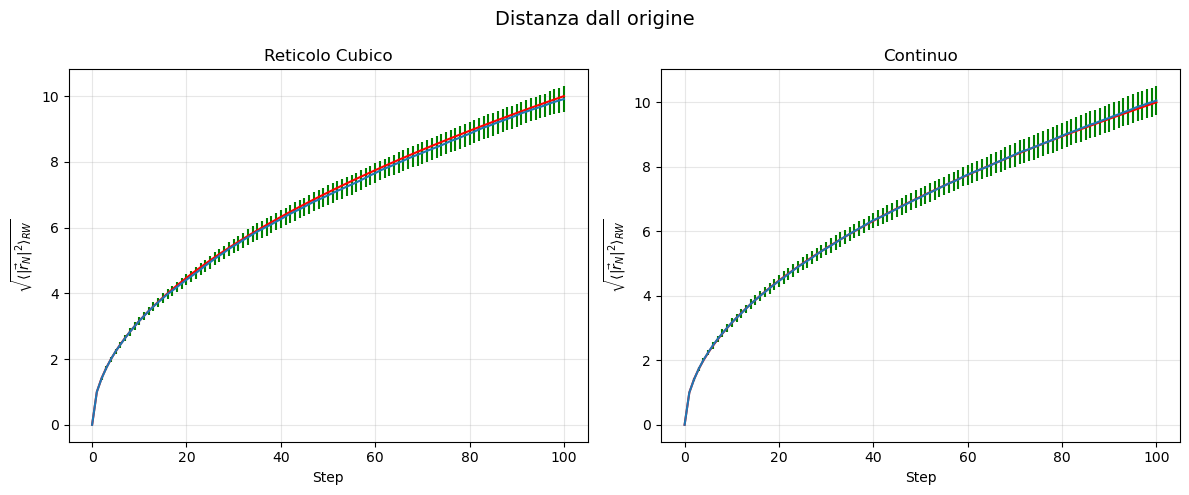

In [14]:
data1 = np.loadtxt("sim_num_es02.2/continuous.dat")
pass1 = data1[:, 0]
int1 = data1[:, 1]
err1 = data1[:, 2]

data2 = np.loadtxt("sim_num_es02.2/lattice.dat")
pass2 = data2[:, 0]
int2 = data2[:, 1]
err2 = data2[:, 2]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.errorbar(pass1, int1, yerr=err1*10, ecolor='green', label="Continuo (errore amplificato di un fattore 10x)")
ax1.plot(pass1, np.sqrt(pass1), color = "red", label=(r"$\sqrt(x)$"))
ax1.set_xlabel("Step")
ax1.set_ylabel(r"$\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$")
ax1.set_title("Reticolo Cubico")
ax1.grid(True, alpha=0.3)

ax2.errorbar(pass2, int2, yerr=err2*10, ecolor='green', label="Reticolo cubico (errore amplificato di un fattore 10x)")
ax2.plot(pass2, np.sqrt(pass2), color = "red", label=(r"$\sqrt(x)$"))
ax2.set_xlabel("Step")
ax2.set_ylabel(r"$\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$")
ax2.set_title("Continuo")
ax2.grid(True, alpha=0.3)

fig.suptitle('Distanza dall origine', fontsize=14)

plt.tight_layout()
plt.show()

## Commento

Si osserva che l'andamento delle due simulazioni è molto simile, nonostante le modalità di campionamento siano differenti. In entrambi i casi, i risultati numerici seguono con buona accuratezza l'andamento teorico proporzionale a $\sqrt{N}$, mostrando una buona sovrapposizione tra i dati simulati e la curva teorica con $k=1$.

Questo risultato conferma che il comportamento diffusivo della Random Walk non dipende dalla modalità con cui viene campionato lo spazio. In entrambi i casi, infatti, i passi sono indipendenti e isotropi, per cui la distanza quadratica media cresce linearmente con il numero di passi,

$$
\langle r^2\rangle \propto N,
$$

e di conseguenza

$$
\sqrt{\langle r^2\rangle}\propto\sqrt{N}.
$$

Il comportamento ottenuto è quindi coerente con la natura diffusiva della Random Walk. Il processo è inoltre di Markov, poiché la probabilità di effettuare il passo successivo dipende solamente dalla posizione corrente e non dalla storia precedente della traiettoria.

Per quanto riguarda le incertezze, si osserva una loro tendenza ad aumentare all'aumentare del numero di passi, pur rimanendo relativamente contenute. Questo comportamento è legato alla crescente dispersione delle traiettorie: aumentando il numero di passi, aumenta infatti la variabilità della distanza raggiunta dalle diverse random walk e, di conseguenza, la dispersione statistica della quantità misurata.
